In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch7. 라이브러리를 이용한 시계열 데이터 분석</font>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [5]:
# data.go.kr
df = pd.read_csv('data/일별_평균_대기오염도정보_2025.csv', encoding='cp949')
df.tail()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
18245,20251231,행주,0.0025,0.0293,0.59,0.0030,17.0,7.0
18246,20251231,마포아트센터,0.0085,0.0296,0.51,0.0036,20.0,7.0
18247,20251231,서울숲,0.0092,0.0279,0.43,0.0037,22.0,7.0
18248,20251231,올림픽공원,0.0057,0.0283,0.49,0.0031,17.0,8.0
18249,20251231,자연사박물관,0.0088,0.0300,0.50,0.0037,21.0,10.0


In [14]:
# 특정 열의 결측치 확인
df[df['이산화질소농도(ppm)'].isna()].head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
3076,20250303,강변북로,NaN,0.0421,NaN,0.0023,13.0,4.0
4004,20250322,관악구,NaN,NaN,NaN,NaN,NaN,NaN
4054,20250323,관악구,NaN,NaN,NaN,NaN,NaN,NaN
4104,20250324,관악구,NaN,NaN,NaN,NaN,NaN,NaN
6840,20250517,관악산,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# 결측치가 존재하는 모든 열 확인
df[df.isna().any(axis=1)].head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
225,20250105,강남대로,0.0298,0.0099,0.80,NaN,36.0,27.0
275,20250106,강남대로,0.0271,0.0137,0.87,NaN,62.0,48.0
582,20250112,영등포로,0.0386,0.0119,NaN,0.0026,36.0,22.0
886,20250118,청계천로,0.0497,NaN,0.85,0.0034,51.0,30.0
986,20250120,청계천로,0.0470,NaN,1.06,0.0036,107.0,80.0


In [12]:
# 모든 측정소명 결측치 수 
df.loc[df.isna().any(axis=1), '측정소명'].value_counts()

금천구       37
화랑로       19
강동구       15
도봉구       11
중랑구       11
관악산        9
도산대로       8
종로         7
종로구        6
강남대로       6
강북구        5
관악구        5
성북구        2
항동         2
중구         2
세곡         2
강변북로       2
청계천로       2
동작구        2
영등포로       1
구로구        1
용산구        1
홍릉로        1
북한산        1
마포아트센터     1
Name: 측정소명, dtype: int64

In [13]:
# 결측치가 있는 측정소명 수 
len(df.loc[df.isna().any(axis=1), '측정소명'].value_counts())

25

In [16]:
# 측정소명 확인
df['측정소명'].unique()

array(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
       '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
       '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구', '강남대로', '강변북로',
       '공항대로', '도산대로', '동작대로', '시흥대로', '신촌로', '영등포로', '정릉로', '종로', '천호대로',
       '청계천로', '한강대로', '홍릉로', '화랑로', '관악산', '남산', '북한산', '세곡', '항동', '행주',
       '마포아트센터', '서울숲', '올림픽공원', '자연사박물관'], dtype=object)

In [17]:
# 측정소명 수 확인
df['측정소명'].nunique()

50

In [23]:
# pd.to_datetime(df['측정일시']) - ms 단위로 인식
# 측정일시 컬럼 타입 변경 순서 : int → str → datetime
df['측정일시'] = pd.to_datetime(df['측정일시'].astype(str))

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  datetime64[ns]
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18185 non-null  float64       
 3   오존농도(ppm)     18163 non-null  float64       
 4   일산화탄소농도(ppm)  18156 non-null  float64       
 5   아황산가스농도(ppm)  18167 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18175 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18166 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.1+ MB


In [32]:
df[df['측정소명']=='서울숲'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 47 to 18247
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    datetime64[ns]
 1   측정소명          365 non-null    object        
 2   이산화질소농도(ppm)  365 non-null    float64       
 3   오존농도(ppm)     365 non-null    float64       
 4   일산화탄소농도(ppm)  365 non-null    float64       
 5   아황산가스농도(ppm)  365 non-null    float64       
 6   미세먼지농도(㎍/㎥)   365 non-null    float64       
 7   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 25.7+ KB


In [48]:
# 에러 발생 예시 : 결측치가 있는 데이터의 시계열 분석
loc_name = '관악구'
df_err = df[df['측정소명']==loc_name]
df_err.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
4,2025-01-01,관악구,0.0326,0.0186,0.55,0.0032,37.0,21.0
54,2025-01-02,관악구,0.0279,0.0192,0.49,0.0031,31.0,19.0
104,2025-01-03,관악구,0.0216,0.0217,0.39,0.0028,20.0,14.0
154,2025-01-04,관악구,0.0289,0.0187,0.48,0.0029,27.0,19.0
204,2025-01-05,관악구,0.0302,0.0166,0.51,0.0022,27.0,22.0


In [49]:
# 결측치가 없는 데이터의 시계열 분석
loc_name = '서울숲'
df_flt = df[df['측정소명']==loc_name]
df_flt.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
47,2025-01-01,서울숲,0.0271,0.0198,0.60,0.0033,40.0,20.0
97,2025-01-02,서울숲,0.0264,0.0202,0.65,0.0032,35.0,18.0
147,2025-01-03,서울숲,0.0162,0.0220,0.45,0.0031,23.0,13.0
197,2025-01-04,서울숲,0.0238,0.0130,0.50,0.0026,34.0,21.0
247,2025-01-05,서울숲,0.0233,0.0108,0.61,0.0025,35.0,30.0


Text(0, 0.5, '먼지농도(㎍/㎥)')

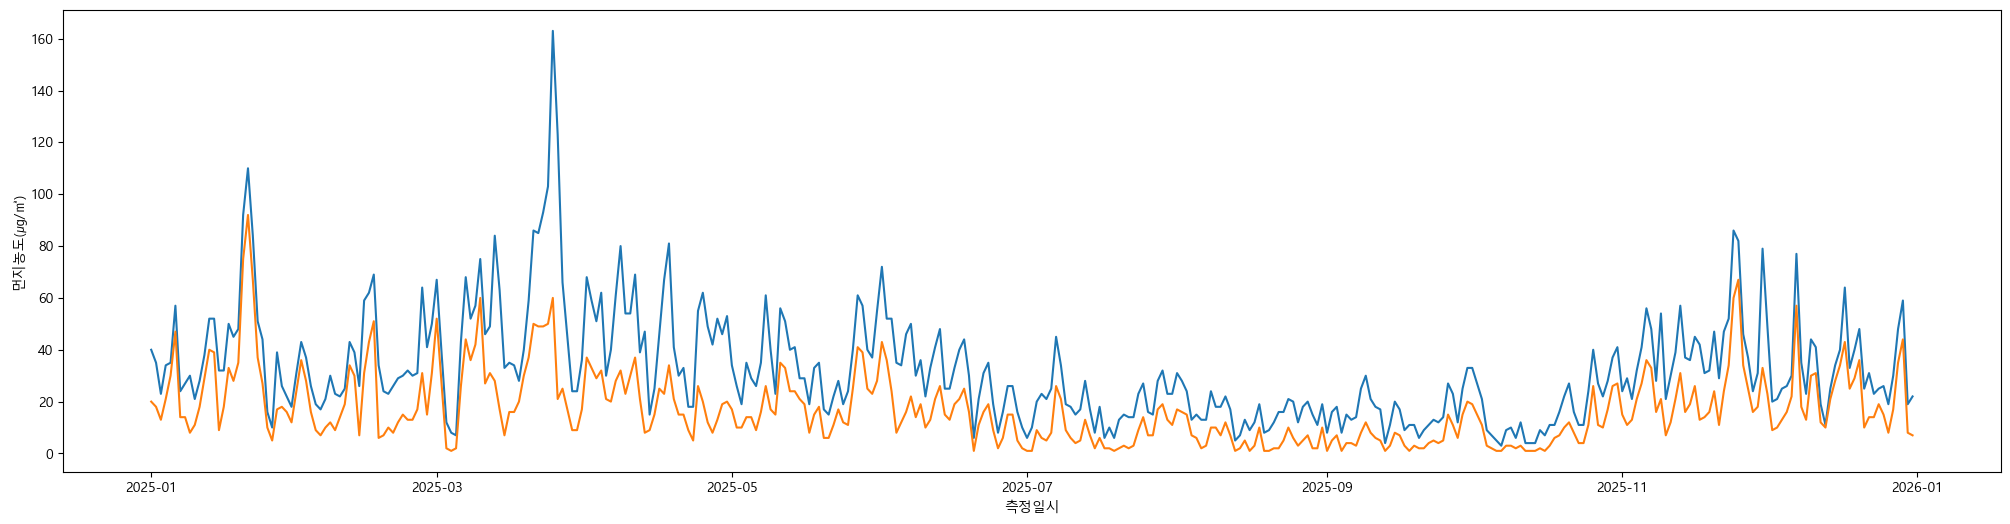

In [50]:
plt.figure(figsize=(25,6))
plt.plot(df_flt['측정일시'], df_flt['미세먼지농도(㎍/㎥)'])
plt.plot(df_flt['측정일시'], df_flt['초미세먼지농도(㎍/㎥)'])
plt.xlabel('측정일시')
plt.ylabel('먼지농도(㎍/㎥)')

# 1. statsmodels
- 데이터가 가진 트렌드, 계절성를 수학적으로 분리하여 주기적인 데이터의 특성 파악
- statsmodels 사용 시 데이터 전처리 : 중복 제거, 결측치 채우기, 빈도(간격) 설정
- 날짜 데이터를 반드시 인덱스로 지정

- seasonal_decomposed의 model
    - 1. 덧셈 모델 (model='additive')
$\text{실제값} = \text{추세} + \text{계절성} + \text{잔차}$
    - 2. 곱셈 모델 (model='multiplicative'): 
$\text{실제값} = \text{추세} \times \text{계절성} \times \text{잔차}$


In [51]:
df_flt2 = df_flt[['측정일시', '미세먼지농도(㎍/㎥)']]
ts = df_flt2.set_index('측정일시')

In [52]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2025-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   미세먼지농도(㎍/㎥)  365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [53]:
# 시계열 데이터 주기성 분해
from statsmodels.tsa.seasonal import seasonal_decompose
rslt = seasonal_decompose(
    ts['미세먼지농도(㎍/㎥)'],
    period=30, # 주기
    model='additive' 
)

In [59]:
# rslt.observed   # 실제값 : 원본 미세먼지 농도
# rslt.trend # 추이 : 계절/노이즈가 제거된 장기 변동 흐름
# rslt.seasonal # 계절성 : 30일 주기로 반복되는 패턴 수치
# rslt.resid  # 잔차 : 이벤트성/무작위 노이즈

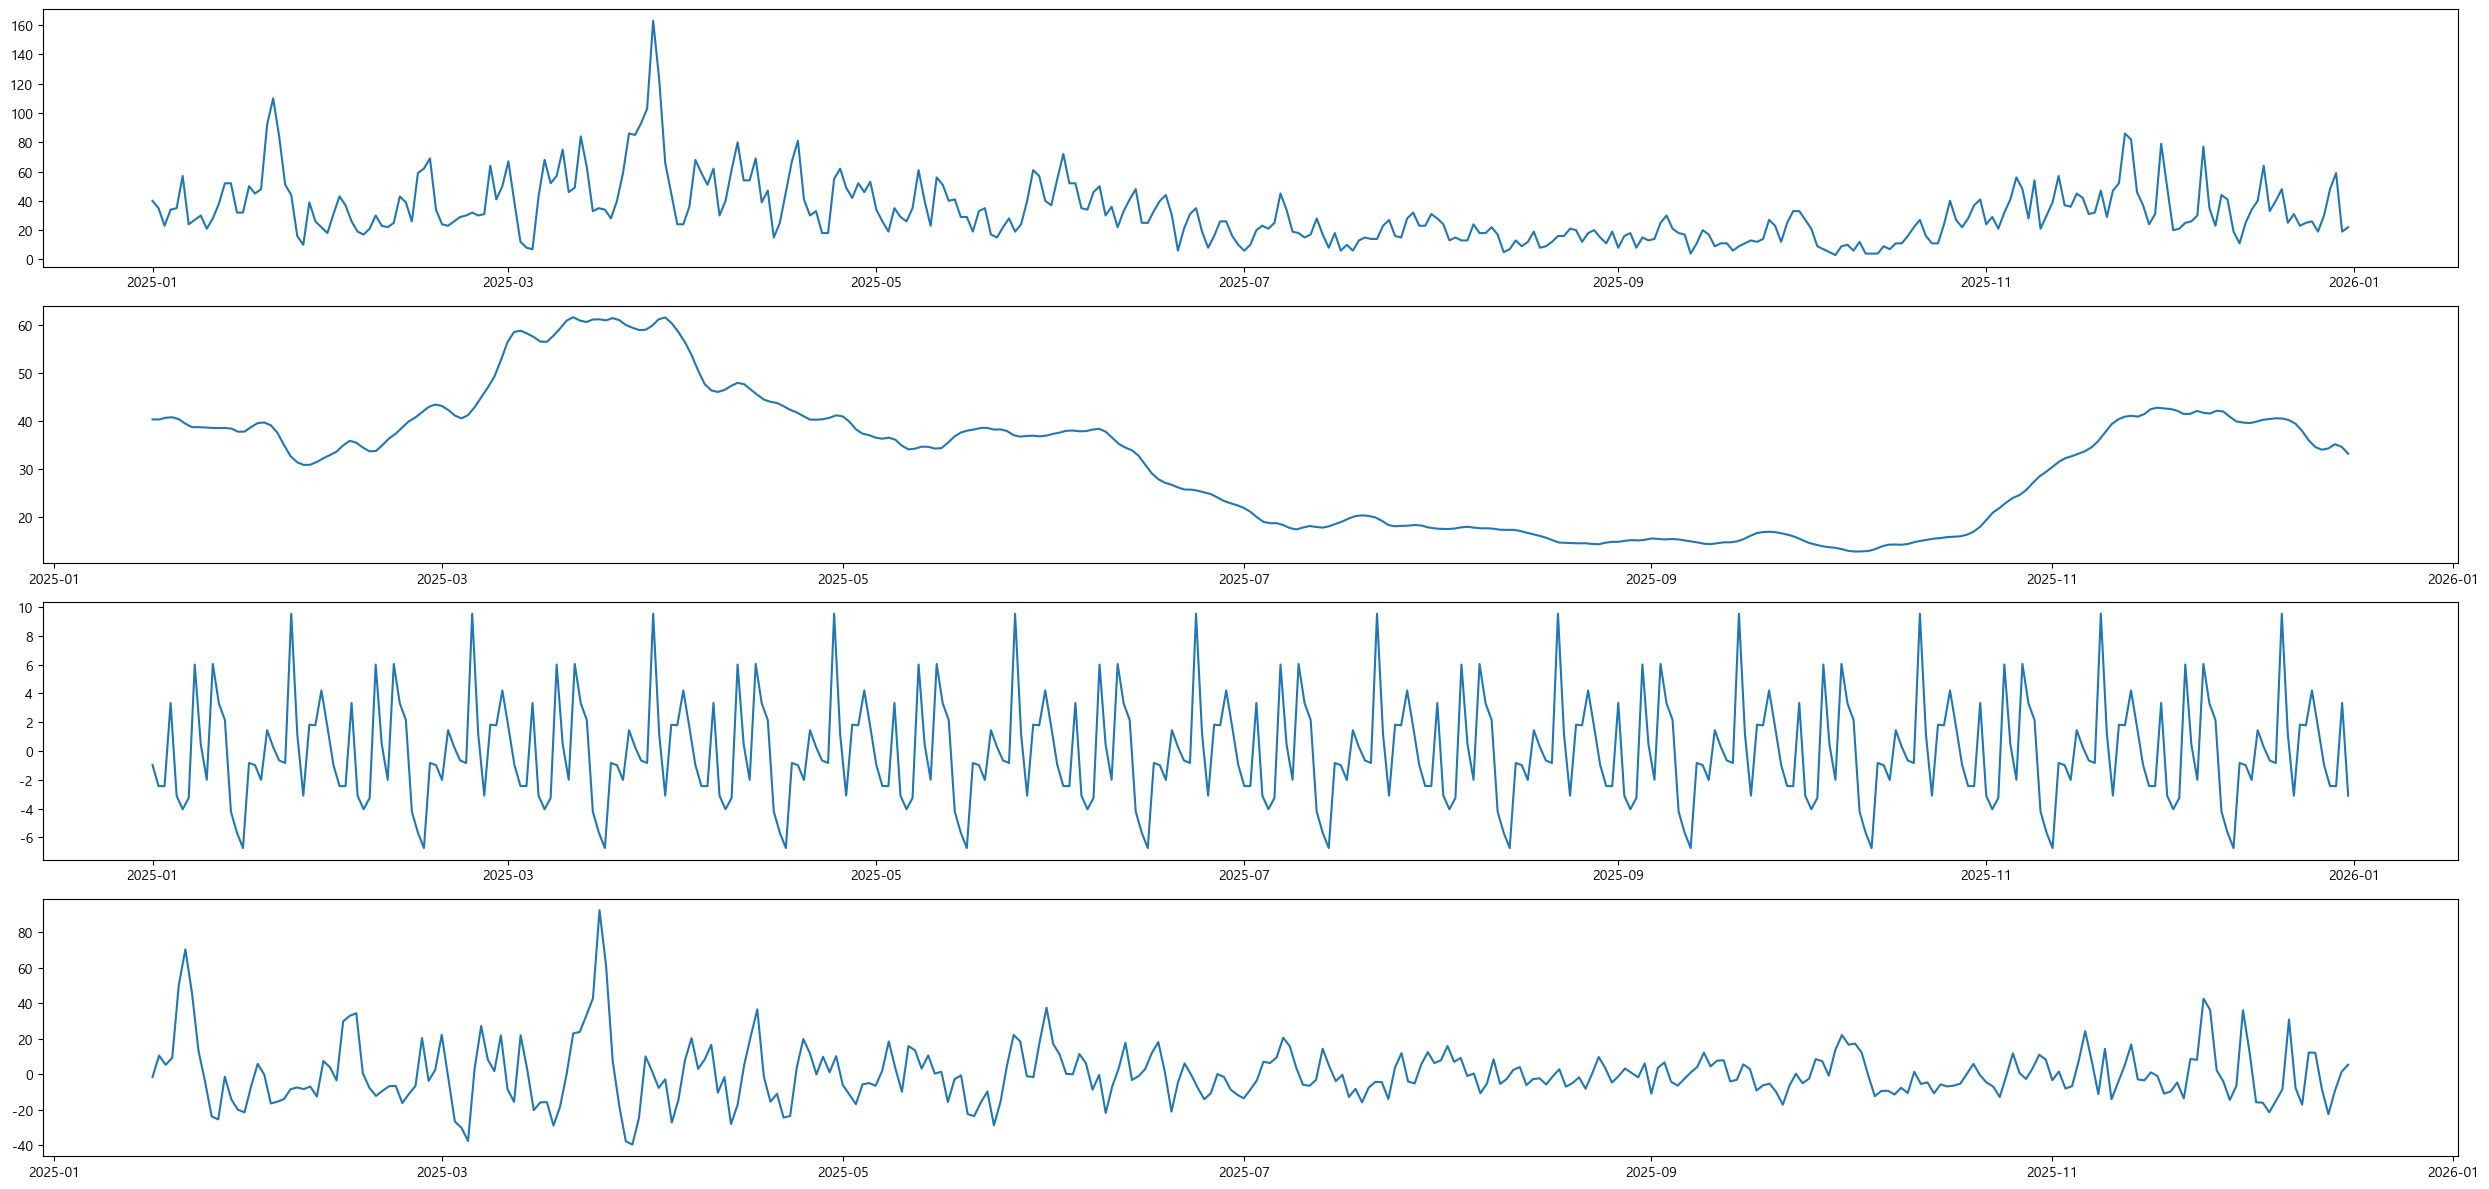

In [65]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(25,12))
axes[0].plot(rslt.observed)
axes[1].plot(rslt.trend)
axes[2].plot(rslt.seasonal)
axes[3].plot(rslt.resid)
plt.tight_layout()
plt.show()


| 모델/라이브러리 | 용도 |
|---|---|
| seasonal_decompose | 통계적 추이 분석 |
| RNN / LSTM / GRU / Seq2Seq | 딥러닝 기반 예측 |
| Prophet | 추이 분석 및 미래 예측 |

# 2. Prophet
- Meta(구 Facebook)에서 개발한 오픈소스 시계열 예측 라이브러리
- 트렌드, 강력한 계절성, 그리고 휴일 효과가 결합된 시계열 데이터 분석 도구
- 누락된 날짜(결측치)가 있거나 불규칙한 간격의 데이터도 전처리 없이 강력하게 예측
- Prophet 사용 시 데이터 조건 : 데이터프레임의 컬럼 이름을 반드시 'ds(날짜 컬럼)', 'y(타겟 변수)'로 지정

In [67]:
df_flt2.columns = ['ds','y']

In [68]:
df_flt2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 47 to 18247
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      365 non-null    datetime64[ns]
 1   y       365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.6 KB


In [69]:
from prophet import Prophet

# 모델 생성
p_model = Prophet()

# 모델 학습
p_model.fit(df_flt2)

14:50:23 - cmdstanpy - INFO - Chain [1] start processing
14:50:24 - cmdstanpy - INFO - Chain [1] done processing


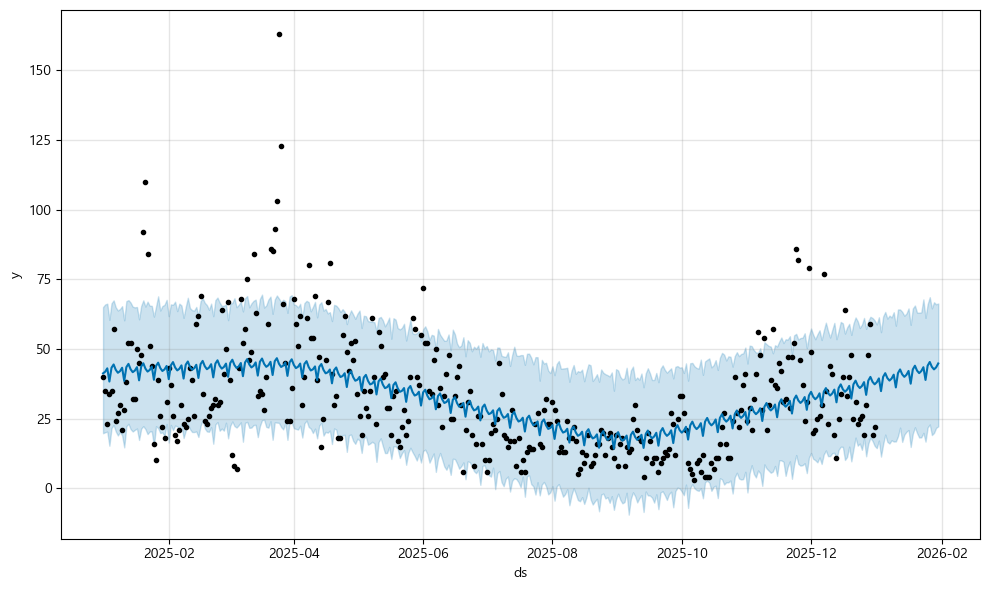

In [73]:
# p_model을 이용하여 30일 이후의 데이터 예측 및 추이 분석

# 미래 데이터 프레임 생성 (30일 예측)
future = p_model.make_future_dataframe(periods=30)

# 예측 수행
forecast = p_model.predict(future)

# 시각화
p = p_model.plot(forecast)

In [76]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend']].tail(30)

,ds,yhat,yhat_lower,yhat_upper,trend
365,2026-01-01,38.048339,14.419555,58.825966,38.266903
366,2026-01-02,39.444223,17.131240,61.379174,38.458157
367,2026-01-03,34.874055,11.378680,56.034197,38.649410
368,2026-01-04,39.982713,15.777608,61.626145,38.840664
369,2026-01-05,41.318968,19.281613,63.293979,39.031918
370,2026-01-06,39.557226,16.669241,60.882903,39.223171
371,2026-01-07,38.659125,16.081605,61.982393,39.414425
372,2026-01-08,39.387114,17.246363,61.320853,39.605678
373,2026-01-09,40.782998,16.788205,63.189776,39.796932
374,2026-01-10,36.212830,16.810978,58.348225,39.988186


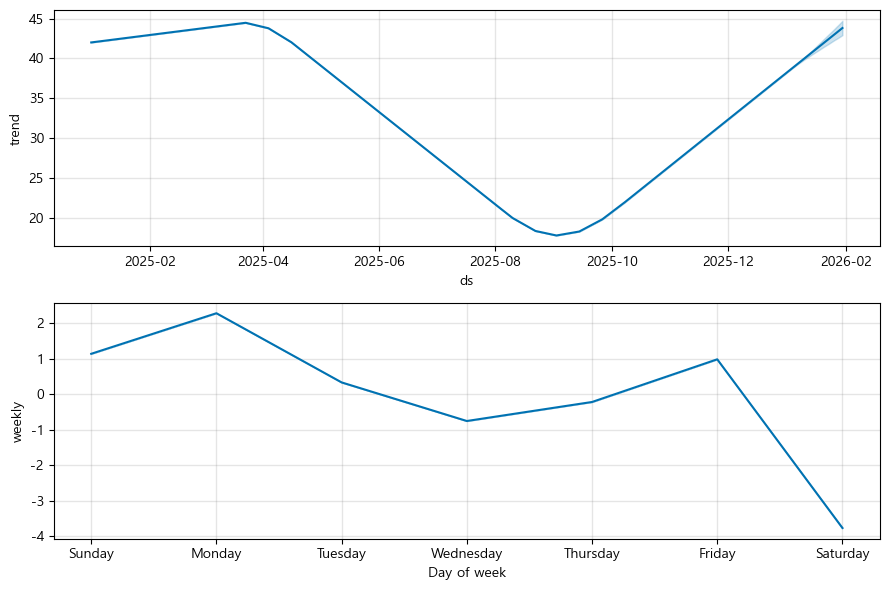

In [78]:
# 트렌드와 휴일 효과 시각화
p = p_model.plot_components(forecast)

In [81]:
forecast.loc[forecast['ds']=='2026-01-15', ['yhat', 'yhat_lower','yhat_upper']]

,yhat,yhat_lower,yhat_upper
379,40.725889,20.306614,62.714075
